#PINN Surrogate Model for Groundwater Head Prediction

This notebook trains and evaluates a Physics-Informed Neural Network (PINN) surrogate model that learns the temporal evolution of hydraulic head fields from MODFLOW simulations. It provides physics-informed evaluation including PDE residuals, mass balance errors, and Dirichlet boundary condition consistency.

Physics-based evaluation covers:
- Metrics (MAE, RMSE, RRMSE, R²)
- Nonlinear Boussinesq PDE residuals
- Finite-volume mass balance error
- Dirichlet boundary condition consistency

**Sections:**
1. Setup & Configuration
2. Model Training
3. Load Trained Model for evaluation
4. Visualization – Spatial Error Maps
5. Physics-Based Evaluation – PDE Residuals & Mass Balance
> 5.1 PDE Residual Evaluation Setup\
    > 5.2 Mass Balance Error (Finite-Volume)
6. Boundary Condition Analysis


## 1. Setup & Configuration

### 1.1 Python imports & device setup

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
import random, os, sys
import torch
import pandas as pd
import numpy as np

import torch.nn as nn
import matplotlib.pyplot as plt

from types import SimpleNamespace
from model import Net, PINN
from problem import Problem

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

# ── Data path configuration ──────────────────────────────────────────────
# Set DATA_DIR to the folder containing your MODFLOW .txt output files.
# Expected file naming convention: t{timestep}.txt  (e.g., t1.txt, t2.txt, ...)
DATA_DIR = './data'  # <-- Change this to your data directory
DATA_PATTERN = os.path.join(DATA_DIR, 't*.txt')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

### 1.2 Set working directory

> **Note:** Replace the path below with your local project directory — the one that contains `train.py`, `test.py`, `model.py`, and `problem.py`.

In [ ]:
# Set this to the directory containing train.py, test.py, model.py, problem.py
PROJECT_DIR = '.'   # <-- Change to your project directory
os.chdir(PROJECT_DIR)
print('Working directory:', os.getcwd())

/content/drive/MyDrive/pinns/unconfined_m


### 1.3 Environment dependencies

> Run this cell once to install required packages not included in the standard PyTorch environment. Safe to skip if already installed.

In [ ]:
!pip install tensorboardX
!pip install pyDOE



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.9/68.9 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 65.1 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.4.2 which is incompatible.
tensorflow 2.19.0 requires numpy<2.2.0,>=1.26.0, but you have numpy 2.4.2 which is incompatible.


## 2. Model Training

### 2.1 Stage 1 — Early transient (t ≤ τ)

Trains the Stage 1 PINN on the early-time domain using Latin Hypercube Sampling for the temporal collocation points.

**Key flags:** `--stage 1 | --temporal_strategy LHS | --nt 200`

In [ ]:
!python train.py --stage 1 --cuda_index 0 --temporal_strategy 'LHS' --nt 200

********************** TRAIN ***********************************
Confined Aquifer Containing A Single Well (Stage 1)
domain=(-500, 500, -500, 500, 0.0, 30.0)
tau=1.0
sigma=30.0
constraint=HARD
layers=[3, 50, 50, 50, 50, 50, 1]
****************************************************************

************** Trainset *****************
Spatial INFO: LR, n=None, nx=None, ny=None, file=./data/well.mat
Temporal INFO: LHS, nt=200, ratio=None
n_xyt      = 693316
n_xy0      = 3680
n_xyt_bdy1 = 19900
n_xyt_bdy2 = 19104
****************************************

--- MODFLOW Dataset Debug ---
stage=1, tau=1.0
   File t0.25.txt            | t= 0.25 | keep=True
   File t0.5.txt             | t= 0.50 | keep=True
   File t0.75.txt            | t= 0.75 | keep=True
   File t1.txt               | t= 1.00 | keep=True
   File t10.txt              | t=10.00 | keep=False
   File t11.txt              | t=11.00 | keep=False
   File t12.txt              | t=12.00 | keep=False
   File t13.txt              | t=13.

### 2.2 Stage 1 — Evaluation

> Runs `test.py` for Stage 1 and writes metrics to the checkpoint directory.

In [ ]:
!python test.py --stage 1 --cuda_index 0 --temporal_strategy 'LHS' --nt 200

************************* TEST *********************************
Confined Aquifer Containing A Single Well (Stage 1)
domain=(-500, 500, -500, 500, 0.0, 30.0)
tau=1.0
sigma=30.0
constraint=HARD
layers=[3, 50, 50, 50, 50, 50, 1]
****************************************************************

*********** Validset *************
Spatial INFO: nx=100, ny=100
Temporal INFO: t = [0.25, 0.5, 0.75, 1]
*********************************

Test loss: 6.0040e-04
Figure(1000x1000)
Figure(1000x1000)
Testing finished successfully!!!



### 2.3 Stage 2 — Late transient (t > τ)

Trains Stage 2 using Stage 1 predictions at t = τ as the initial condition (`--prev_stage_ckpt`).

In [ ]:
!python train.py  --stage 2 --cuda_index 0 --temporal_strategy 'LHS' --nt 200 --temporal_strategy_prev 'LHS' --nt_prev 200 --epochs_Adam 4000

********************** TRAIN ***********************************
Confined Aquifer Containing A Single Well (Stage 2)
domain=(-500, 500, -500, 500, 0.0, 30.0)
tau=1.0
sigma=30.0
constraint=HARD
layers=[3, 50, 50, 50, 50, 50, 1]
****************************************************************

************** Trainset *****************
Spatial INFO: LR, n=None, nx=None, ny=None, file=./data/well.mat
Temporal INFO: LHS, nt=200, ratio=None
n_xyt      = 693316
n_xy0      = 3680
n_xyt_bdy1 = 19900
n_xyt_bdy2 = 19104
****************************************

--- MODFLOW Dataset Debug ---
stage=2, tau=1.0
   File t0.25.txt            | t= 0.25 | keep=False
   File t0.5.txt             | t= 0.50 | keep=False
   File t0.75.txt            | t= 0.75 | keep=False
   File t1.txt               | t= 1.00 | keep=False
   File t10.txt              | t=10.00 | keep=True
   File t11.txt              | t=11.00 | keep=True
   File t12.txt              | t=12.00 | keep=True
   File t13.txt              | t=13

### 2.4 Stage 2 — Evaluation

In [ ]:
!python test.py --stage 2 --cuda_index 0 --temporal_strategy 'LHS' --nt 200 --temporal_strategy_prev 'LHS' --nt_prev 200

************************* TEST *********************************
Confined Aquifer Containing A Single Well (Stage 2)
domain=(-500, 500, -500, 500, 0.0, 30.0)
tau=1.0
sigma=30.0
constraint=HARD
layers=[3, 50, 50, 50, 50, 50, 1]
****************************************************************

*********** Validset *************
Spatial INFO: nx=100, ny=100
Temporal INFO: t = [5, 10, 15, 20]
*********************************

Test loss: 1.7032e-04
Figure(1000x1000)
Figure(1000x1000)
/content/drive/MyDrive/pinns/unconfined_m/trainer.py:909: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv('./modflow/o1.csv',
[[87.4752     87.47537994]
 [84.988      85.12684631]
 [87.8572     87.84673309]
 [83.0082     83.13314056]
 [89.1892     89.17925262]
 [88.61       88.62056732]
 [88.0793     88.06865692]
 [87.5721     87.59265137]
 [86.1083     86.10437775]
 [87.3704     87.34871674]
 [89.1

### 2.5 Training curves (TensorBoard)

> Launches an inline TensorBoard viewer. Point `--logdir` at your checkpoint folder to inspect loss curves for both stages.

In [ ]:
%load_ext tensorboard
# 2) Point to your log directory
#    For PyTorch SummaryWriter default use "runs"
#    For Lightning use "lightning_logs"
logdir = "/content/drive/MyDrive/pinns/unconfined_m/runs"

%tensorboard --logdir $logdir --reload_interval 5

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


Reusing TensorBoard on port 6006 (pid 17013), started 0:03:40 ago. (Use '!kill 17013' to kill it.)

<IPython.core.display.Javascript object>

## 3. Load Trained Model for Evaluation

Loads both stage checkpoints and wraps them in a `TwoStageModel` that automatically routes each query point through the correct stage.

> **Before running:** update `CKPT_S1` and `CKPT_S2` to point at your checkpoint files.

In [ ]:
# ============================================================================
# SETUP: Load PINN Models (Stage 1 + Stage 2)
# ============================================================================
# This cell must run first. It loads both stage models and creates a unified
# `model` object that routes predictions through the correct stage.
# ============================================================================

# ── Configuration ────────────────────────────────────────────────────────
TAU   = 1.0       # Stage boundary (days)
SIGMA = 30.0      # Gaussian well sigma
HIDDEN_LAYERS  = 5
HIDDEN_NEURONS = 50
CONSTRAINT     = 'HARD'
SCALE          = 1.0

# Checkpoint paths — adjust if using different training runs
CKPT_S1 = 'checkpoints/Stage1_HARD_5x50_tau:1_sigma:30_S:LR_T:LHS_nt:200/best_model.pth.tar'
CKPT_S2 = 'checkpoints/Stage2_HARD_5x50_tau:1_sigma:30_S:LR_T:LHS_nt:200/best_model.pth.tar'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
problem = Problem(sigma=SIGMA)

# ── Build args namespace (mimics Options.parse() for notebook use) ───────
def _make_args():
    a = SimpleNamespace()
    a.tau            = TAU
    a.layers         = [3] + HIDDEN_LAYERS * [HIDDEN_NEURONS] + [1]
    a.scale          = SCALE
    a.device         = device
    a.constraint     = CONSTRAINT
    a.problem        = problem
    a.sigma          = SIGMA
    a.hidden_layers  = HIDDEN_LAYERS
    a.hidden_neurons = HIDDEN_NEURONS
    return a

args = _make_args()

# ── Load Stage 1 ─────────────────────────────────────────────────────────
net_s1  = Net(args, stage=1)
pinn_s1 = PINN(net_s1)
ckpt_s1 = torch.load(CKPT_S1, map_location=device, weights_only=False)
pinn_s1.load_state_dict(ckpt_s1['state_dict'])
pinn_s1.to(device)
pinn_s1.eval()
net_s1 = pinn_s1.net

# ── Load Stage 2 ─────────────────────────────────────────────────────────
net_s2  = Net(args, stage=2)
pinn_s2 = PINN(net_s2)
ckpt_s2 = torch.load(CKPT_S2, map_location=device, weights_only=False)
pinn_s2.load_state_dict(ckpt_s2['state_dict'])
pinn_s2.to(device)
pinn_s2.eval()
net_s2 = pinn_s2.net

# ── Unified Two-Stage Model ─────────────────────────────────────────────
class TwoStageModel(nn.Module):
    """
    Transparent wrapper: routes (x, y, t) through the correct stage.

    - t <= tau  ->  Stage 1 network
    - t >  tau  ->  Stage 2 network (with hstar from Stage 1 at t=tau)

    Usage:  h = model(xyt_tensor)   # (N, 3) -> (N, 1)
    """
    def __init__(self, s1, s2, tau, dev):
        super().__init__()
        self.s1  = s1
        self.s2  = s2
        self.tau = tau
        self._dev = dev

    def forward(self, xyt):
        N = xyt.shape[0]
        h = torch.zeros(N, 1, device=self._dev)

        mask_s1 = (xyt[:, 2] <= self.tau)
        mask_s2 = ~mask_s1

        # Stage 1
        if mask_s1.any():
            h[mask_s1] = self.s1(xyt[mask_s1])

        # Stage 2 (needs hstar from Stage 1 at t = tau)
        if mask_s2.any():
            xyt_s2  = xyt[mask_s2]
            xytau   = xyt_s2.clone()
            xytau[:, 2] = self.tau
            hstar   = self.s1(xytau).detach()
            h[mask_s2] = self.s2(xyt_s2, hstar=hstar)

        return h

model = TwoStageModel(net_s1, net_s2, TAU, device)
model.eval()

print(f"Device : {device}")
print(f"Stage 1: {CKPT_S1}")
print(f"Stage 2: {CKPT_S2}")
print(f"Tau={TAU}, Sigma={SIGMA}, Constraint={CONSTRAINT}")
print(f"Architecture: {args.layers}")
print(f"Domain: {problem.domain}")
print("Model ready — model(xyt) handles both stages automatically.")


Device : cuda
Stage 1: checkpoints/Stage1_HARD_5x50_tau:1_sigma:30_S:LR_T:LHS_nt:200/best_model.pth.tar
Stage 2: checkpoints/Stage2_HARD_5x50_tau:1_sigma:30_S:LR_T:LHS_nt:200/best_model.pth.tar
Tau=1.0, Sigma=30.0, Constraint=HARD
Architecture: [3, 50, 50, 50, 50, 50, 1]
Domain: (-500, 500, -500, 500, 0.0, 30.0)
Model ready — model(xyt) handles both stages automatically.


## 4. Visualization – Spatial Error Maps

The cells below produce spatial absolute error maps for the PINN.
> Uses a clipped color scale to reveal low-level spatial error patterns that would otherwise be washed out by pumping-well singularities.


FIGURE 3b: ROBUST ERROR MAPS (Clipped to 99th Percentile)
Found 33 time snapshots: [0.25, 0.5, 0.75, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0, 13.0, 14.0, 15.0, 16.0, 17.0, 18.0, 19.0, 20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27.0, 28.0, 29.0, 30.0]
  t=  0.25 d | RMSE=0.0258 m | Max=0.1318 m
  t=  0.50 d | RMSE=0.0174 m | Max=0.0672 m
  t=  0.75 d | RMSE=0.0317 m | Max=0.1034 m
  t=  1.00 d | RMSE=0.0442 m | Max=0.1308 m
  t=  2.00 d | RMSE=0.0262 m | Max=0.1249 m
  t=  3.00 d | RMSE=0.0135 m | Max=0.0814 m
  t=  4.00 d | RMSE=0.0133 m | Max=0.1030 m
  t=  5.00 d | RMSE=0.0129 m | Max=0.1083 m
  t=  6.00 d | RMSE=0.0126 m | Max=0.1087 m
  t=  7.00 d | RMSE=0.0124 m | Max=0.1099 m
  t=  8.00 d | RMSE=0.0123 m | Max=0.1118 m
  t=  9.00 d | RMSE=0.0122 m | Max=0.1131 m
  t= 10.00 d | RMSE=0.0122 m | Max=0.1130 m
  t= 11.00 d | RMSE=0.0124 m | Max=0.1115 m
  t= 12.00 d | RMSE=0.0127 m | Max=0.1090 m
  t= 13.00 d | RMSE=0.0130 m | Max=0.1061 m
  t= 14.00 d | RMSE=0.01

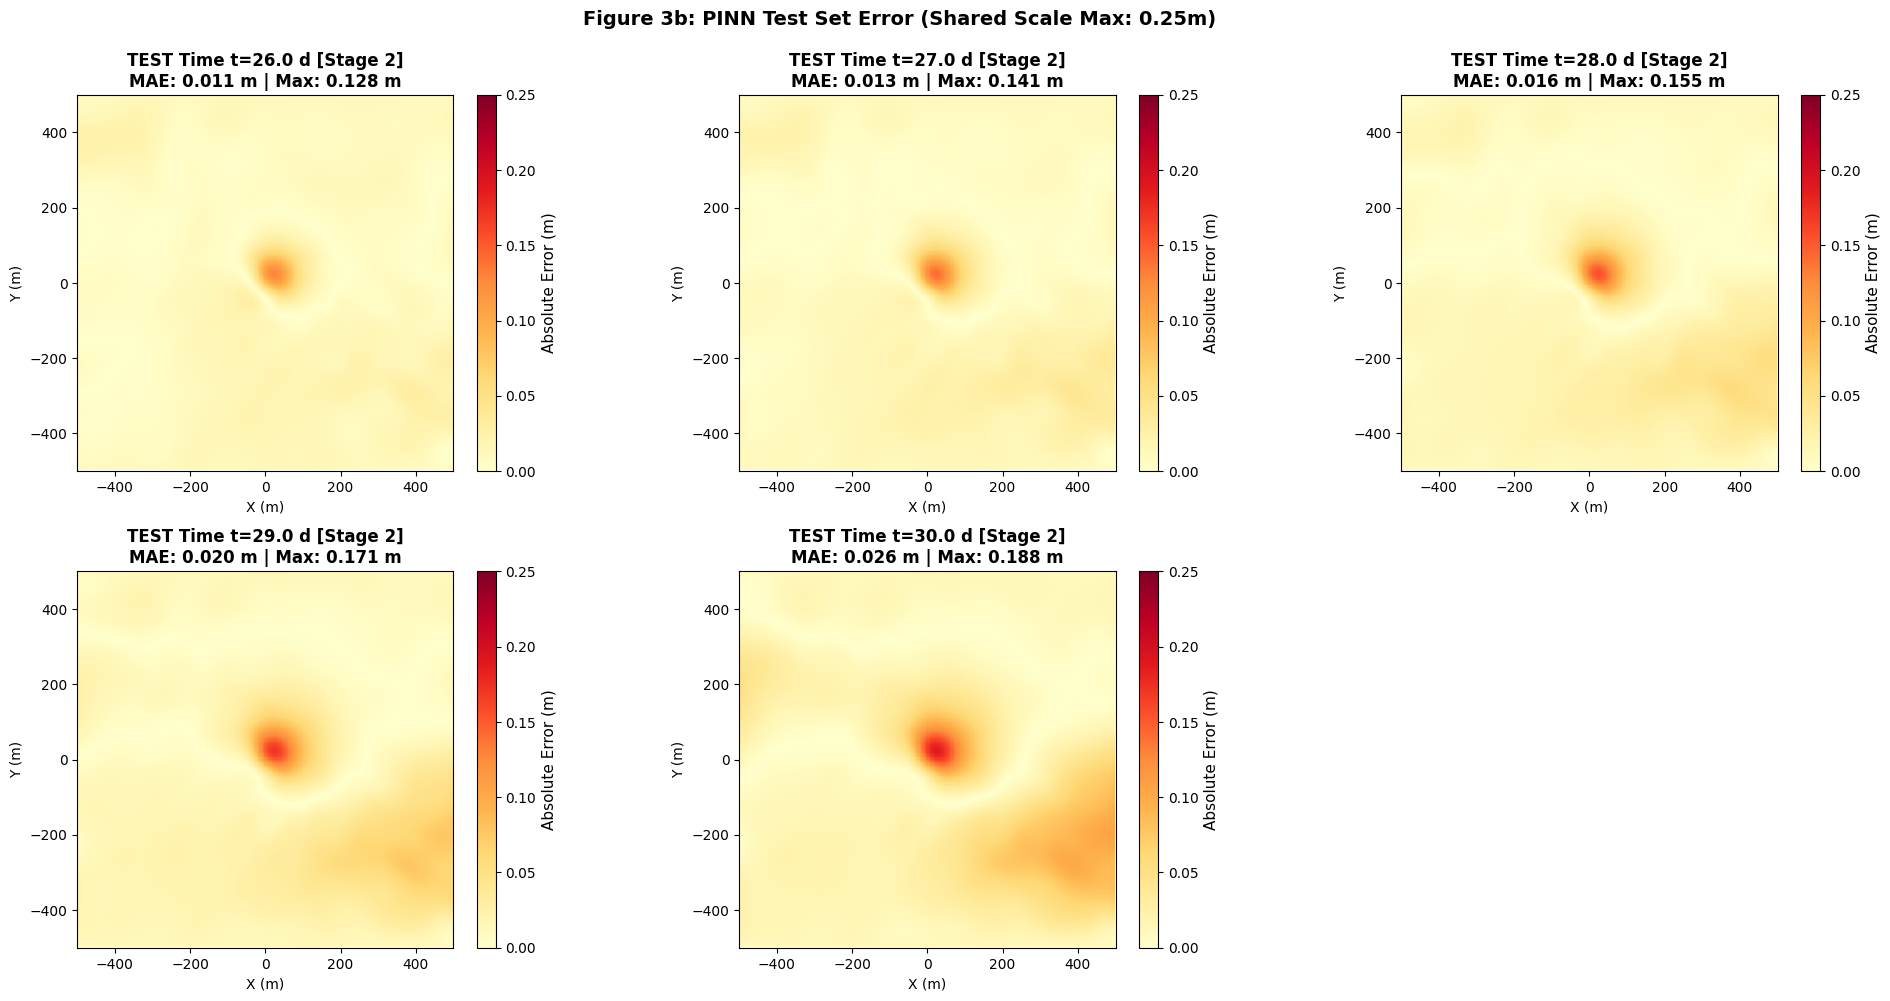

In [ ]:
model.eval()

print("=" * 80)
print("FIGURE 3b: ROBUST ERROR MAPS (Clipped to 99th Percentile)")
print("=" * 80)

# 1. Identify all available MODFLOW time files
pattern = "./modflow/t*.txt" # Corrected path
files = sorted(glob.glob(pattern))

def parse_time(f):
    m = re.search(r't([0-9]+(?:\.[0-9]+)?)', f)
    return float(m.group(1)) if m else None

# Collect ALL available time files (TwoStageModel handles stage routing)
time_files = []
for f in files:
    t_val = parse_time(f)
    if t_val is not None:
        time_files.append((t_val, f))

time_files.sort(key=lambda x: x[0])
times = [t for t, f in time_files]

print(f"Found {len(times)} time snapshots: {times}")

# # 2. Setup Grid (aligned with PINN domain [-500, 500])
# nx, ny = 300, 300
# x_min, x_max = -500, 500
# y_min, y_max = -500, 500
# x = np.linspace(x_min, x_max, nx)
# y = np.linspace(y_min, y_max, ny)
# grid_x, grid_y = np.meshgrid(x, y)
# xy_grid = np.vstack([grid_x.ravel(), grid_y.ravel()]).T  # (N, 2)

# 3. Compute RMSE for ALL timesteps to find max-error period
rmse_per_timestep = []
error_maps = {}  # Cache error maps to avoid re-computing

with torch.no_grad():
    for t_val, f_path in time_files:
        # A. Load MODFLOW Ground Truth
        try:
            df = pd.read_csv(f_path, sep=r'\s*,\s*|\s+', engine="python",
                             header=None, names=['x', 'y', 'h'])
            df = df.apply(pd.to_numeric, errors='coerce').dropna()

            # Shift MODFLOW coords to PINN domain (0..1000 -> -500..500)
            if df['x'].min() >= 0:
                points = df[['x', 'y']].values - 500.0
            else:
                points = df[['x', 'y']].values

            values = df['h'].values

            # Interpolate to grid
            # Get structured grid directly
            x_unique = np.sort(df['x'].unique())
            y_unique = np.sort(df['y'].unique())

            # Shift to PINN domain
            # x_unique = x_unique - 500
            # y_unique = y_unique - 500

            grid_x, grid_y = np.meshgrid(x_unique, y_unique)

            # Reshape directly (no interpolation)
            grid_h_true = df['h'].values.reshape(len(y_unique), len(x_unique))

            mask = np.ones_like(grid_h_true, dtype=bool)


        except Exception as e:
            print(f"Error loading {f_path}: {e}")
            rmse_per_timestep.append(0.0)
            continue

        # B. PINN Prediction — (x, y, t) input
        t_vec = np.full((xy_grid.shape[0], 1), t_val)
        xyt_input = np.hstack([xy_grid, t_vec])
        xyt_tensor = torch.from_numpy(xyt_input).float().to(device)

        h_pred_tensor = model(xyt_tensor)
        grid_h_pred = h_pred_tensor.cpu().numpy().reshape(ny, nx)

        # C. Compare (valid pixels only)
        diff = grid_h_pred[mask] - grid_h_true[mask]
        rmse = np.sqrt(np.mean(diff**2))
        rmse_per_timestep.append(rmse)

        full_diff = np.abs(grid_h_pred - grid_h_true)
        error_maps[t_val] = full_diff

        print(f"  t={t_val:6.2f} d | RMSE={rmse:.4f} m | Max={np.nanmax(full_diff):.4f} m")

rmse_per_timestep = np.array(rmse_per_timestep)

# ============================================================================
# Figure 3b: Robust Spatial Error Map (TEST SET ONLY: LAST 5 SNAPSHOTS)
# ============================================================================
# ... [Sections 1, 2, and 3 remain the same as your provided code] ...

rmse_per_timestep = np.array(rmse_per_timestep)

# 4. Select Indices (EXCLUSIVELY THE LAST 5 SNAPSHOTS - TEST SET)
num_test_snapshots = 5

if len(times) < num_test_snapshots:
    print(f"Warning: Only found {len(times)} snapshots. Plotting all available.")
    selected_indices = list(range(len(times)))
else:
    # Explicitly take the last 5 indices
    selected_indices = list(range(len(times) - num_test_snapshots, len(times)))

print(f"Evaluating Test Set indices: {selected_indices}")
print(f"Test Set times: {[times[i] for i in selected_indices]} days")

# Collect valid errors for Robust Scaling (99th percentile) across the TEST SET
all_valid_errors = []
plot_data = []

for idx in selected_indices:
    t_val = times[idx]
    err_map = error_maps[t_val]
    valid_errs = err_map[~np.isnan(err_map)]
    all_valid_errors.append(valid_errs)
    plot_data.append((t_val, err_map))

all_valid_errors_flat = np.concatenate(all_valid_errors)

# Calculate Robust Scale based on the Test Set distribution
vmax_robust = np.percentile(all_valid_errors_flat, 99)
max_real = np.max(all_valid_errors_flat)

print(f"\nTEST SET STATISTICS:")
print(f"True Maximum Error:   {max_real:.4f} m")
print(f"99th Percentile Cap:  {vmax_robust:.4f} m")

# Plot (Adjusting to a 1x5 or 2x3 layout since we have 5 snapshots)
fig = plt.figure(figsize=(20, 10))

for plot_idx, (t_val, abs_error) in enumerate(plot_data):
    # Using a 2x3 grid to accommodate 5 snapshots
    ax = fig.add_subplot(2, 3, plot_idx + 1)

    im = ax.imshow(abs_error, cmap='YlOrRd', interpolation='nearest',
                   extent=[x_min, x_max, y_min, y_max], origin='lower',
                   vmin=0, vmax=0.25) ###adjust the max for the plots for fairness!!!

    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('Absolute Error (m)', fontsize=11)

    valid_mask = ~np.isnan(abs_error)
    mae_val = np.mean(abs_error[valid_mask])
    local_max = np.max(abs_error[valid_mask])

    ax.set_title(
        f'TEST Time t={t_val} d [Stage 2]\n'
        f'MAE: {mae_val:.3f} m | Max: {local_max:.3f} m',
        fontsize=12, fontweight='bold'
    )

    ax.set_xlabel('X (m)')
    ax.set_ylabel('Y (m)')
    ax.set_aspect('equal')

plt.suptitle(f'Figure 3b: PINN Test Set Error (Shared Scale Max: 0.25m)',
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout(pad=1.0)
plt.show()

## 5. Physics-Based Evaluation – PDE Residuals & Mass Balance

Evaluates the CNN against the nonlinear Boussinesq groundwater flow equation:

$$R = S_y \frac{\partial h}{\partial t} - K \left[ h \nabla^2 h + (\nabla h)^2 \right] - f$$



### 5.1 PDE Residual Evaluation Setup

In [ ]:
# ============================================================================
# C1. PDE Residual Evaluation (NONLINEAR BOUSSINESQ — BACKGROUND vs SOURCE ZONE)
# ============================================================================
# Governing PDE (unconfined Boussinesq, matching model.py Net_PDE):
#   Sy·∂h/∂t = K·[h·∇²h + (∇h)²] + f
#
# Residual:  R = Sy·∂h/∂t − K·[h·∇²h + hx² + hy²] − f
# ============================================================================

import pandas as pd

model.eval()

# ---------------------------------------------------------
# 1. Physical Parameters & Grid
# ---------------------------------------------------------
K   = 33.33    # Hydraulic conductivity (m/day)
mu  = 0.10     # Specific yield
sigma_well = 30.0   # Gaussian well sigma (m)
Q_well = -40000.0   # Pumping rate (m³/day)

nx, ny = 300, 300
x_val = np.linspace(-500, 500, nx)
y_val = np.linspace(-500, 500, ny)
dx = x_val[1] - x_val[0]
dy = y_val[1] - y_val[0]
dt_eval = 0.01   # Small dt for accurate temporal derivative

grid_x_val, grid_y_val = np.meshgrid(x_val, y_val)
xy_grid_val = np.vstack([grid_x_val.ravel(), grid_y_val.ravel()]).T

# ---------------------------------------------------------
# 2. Source Term Field (Gaussian well on interior grid)
# ---------------------------------------------------------
x_int = x_val[1:-1]
y_int = y_val[1:-1]
gx_int, gy_int = np.meshgrid(x_int, y_int)  # (ny-2, nx-2)
r2_int = gx_int**2 + gy_int**2
f_field = Q_well / (2 * np.pi * sigma_well**2) * np.exp(-r2_int / (2 * sigma_well**2))

# Distance mask for zone-based statistics
dist_int = np.sqrt(r2_int)
mask_bg   = dist_int > 3 * sigma_well   # Background: r > 3σ (90m)
mask_well = dist_int <= 3 * sigma_well   # Source zone: r ≤ 3σ

print(f"Grid: {nx}×{ny}, dx={dx:.2f}m, dy={dy:.2f}m, dt={dt_eval}d")
print(f"Interior background cells:  {mask_bg.sum()}")
print(f"Interior source-zone cells: {mask_well.sum()}")

# ---------------------------------------------------------
# 2. Nonlinear Boussinesq Operator
# ---------------------------------------------------------
def nonlinear_pde_terms(h, dx, dy):
    """
    Compute h·∇²h + (∇h)² on interior cells via central FD.
    Returns (ny-2, nx-2) array.
    """
    h_int = h[1:-1, 1:-1]

    # Laplacian (central differences)
    lap = ((h[1:-1, 2:] - 2*h_int + h[1:-1, :-2]) / dx**2 +
           (h[2:, 1:-1] - 2*h_int + h[:-2, 1:-1]) / dy**2)

    # Squared gradients (central differences)
    hx = (h[1:-1, 2:] - h[1:-1, :-2]) / (2 * dx)
    hy = (h[2:, 1:-1] - h[:-2, 1:-1]) / (2 * dy)

    return h_int * lap + hx**2 + hy**2

# ---------------------------------------------------------
# 3. Evaluate Residuals per Timestep
# ---------------------------------------------------------
if 'times' not in globals():
    times = [0.25, 0.5, 0.75, 1.0, 5.0, 10.0, 15.0, 20.0, 25.0, 30.0]

print("=" * 100)
print("C1. PDE RESIDUAL — NONLINEAR BOUSSINESQ")
print("R = Sy·∂h/∂t − K·[h·∇²h + hx² + hy²] − f")
print("-" * 100)
print(f"{'Time':<8} | {'Overall RMSE':<14} | {'BG Mean|R|':<12} | {'BG RMSE':<12} | "
      f"{'Well RMSE':<12} | {'Max |R|':<10}")
print("-" * 100)

residuals_all = []
residuals_bg_all = []
sample_stats = []

with torch.no_grad():
    for t_val in times:
        # A. Predict h(t) and h(t-dt)
        t_vec = np.full((xy_grid_val.shape[0], 1), t_val)
        xyt = np.hstack([xy_grid_val, t_vec])
        h_t = model(torch.from_numpy(xyt).float().to(device)).cpu().numpy().reshape(ny, nx)

        t_vec_p = np.full((xy_grid_val.shape[0], 1), t_val - dt_eval)
        xyt_p = np.hstack([xy_grid_val, t_vec_p])
        h_prev = model(torch.from_numpy(xyt_p).float().to(device)).cpu().numpy().reshape(ny, nx)

        # B. Nonlinear physics: h·∇²h + (∇h)²
        physics = nonlinear_pde_terms(h_t, dx, dy)

        # C. Temporal derivative on interior
        dh_dt = (h_t[1:-1, 1:-1] - h_prev[1:-1, 1:-1]) / dt_eval

        # D. Full residual: R = Sy·∂h/∂t − K·physics − f
        R = mu * dh_dt - K * physics - f_field

        # E. Zone statistics
        overall_rmse = np.sqrt(np.mean(R**2))
        bg_mean_abs  = np.mean(np.abs(R[mask_bg]))
        bg_rmse      = np.sqrt(np.mean(R[mask_bg]**2))
        well_rmse    = np.sqrt(np.mean(R[mask_well]**2))
        max_abs_R    = np.max(np.abs(R))

        print(f"{t_val:<8.2f} | {overall_rmse:<14.4f} | {bg_mean_abs:<12.5f} | "
              f"{bg_rmse:<12.5f} | {well_rmse:<12.4f} | {max_abs_R:<10.2f}")

        residuals_all.append(R.flatten())
        residuals_bg_all.append(R[mask_bg].flatten())
        sample_stats.append({
            'Time (d)': t_val,
            'Overall RMSE': overall_rmse,
            'BG Mean|R|': bg_mean_abs,
            'BG RMSE': bg_rmse,
            'Well RMSE': well_rmse,
            'Max |R|': max_abs_R,
        })

# ---------------------------------------------------------
# 4. Overall Summary
# ---------------------------------------------------------
all_R  = np.concatenate(residuals_all)
all_bg = np.concatenate(residuals_bg_all)

print("=" * 100)
print(f"{'OVERALL':<8} | {np.sqrt(np.mean(all_R**2)):<14.4f} | "
      f"{np.mean(np.abs(all_bg)):<12.5f} | {np.sqrt(np.mean(all_bg**2)):<12.5f} | "
      f"{'—':<12} | {np.max(np.abs(all_R)):<10.2f}")
print("=" * 100)

df_residuals = pd.DataFrame(sample_stats)
print("\nTABLE 2: PDE Residual Statistics")
print(df_residuals.to_string(index=False))

Grid: 300×300, dx=3.34m, dy=3.34m, dt=0.01d
Interior background cells:  86520
Interior source-zone cells: 2284
C1. PDE RESIDUAL — NONLINEAR BOUSSINESQ
R = Sy·∂h/∂t − K·[h·∇²h + hx² + hy²] − f
----------------------------------------------------------------------------------------------------
Time     | Overall RMSE   | BG Mean|R|   | BG RMSE      | Well RMSE    | Max |R|   
----------------------------------------------------------------------------------------------------
0.25     | 0.0164         | 0.00814      | 0.01172      | 0.0727       | 0.18      
0.50     | 0.0098         | 0.00705      | 0.00926      | 0.0221       | 0.05      
0.75     | 0.0188         | 0.01240      | 0.01718      | 0.0508       | 0.11      
1.00     | 0.0416         | 0.02160      | 0.03061      | 0.1783       | 0.44      
2.00     | 0.0177         | 0.01179      | 0.01603      | 0.0501       | 0.20      
3.00     | 0.0171         | 0.01051      | 0.01438      | 0.0594       | 0.25      
4.00     | 0.0172 

### 5.2  Mass Balance Error (Finite-Volume)

Time series of volumetric mass balance error

Mass balance grid: 300x300, dx=3.34m, dy=3.34m
Evaluating Mass Balance over 60 timesteps...

MASS BALANCE SUMMARY
Mean Abs Residual:       1009.4 m³/day
Max  Abs Residual:      20386.4 m³/day
Mean Rel Error:            2.52 %  (of |Q_well|=40000)
Boundary inflow (t=1):      2074.6 m³/day
Boundary inflow (t=30):    40243.2 m³/day
Storage rate    (t=1):    -17539.0 m³/day
Storage rate    (t=30):        8.9 m³/day


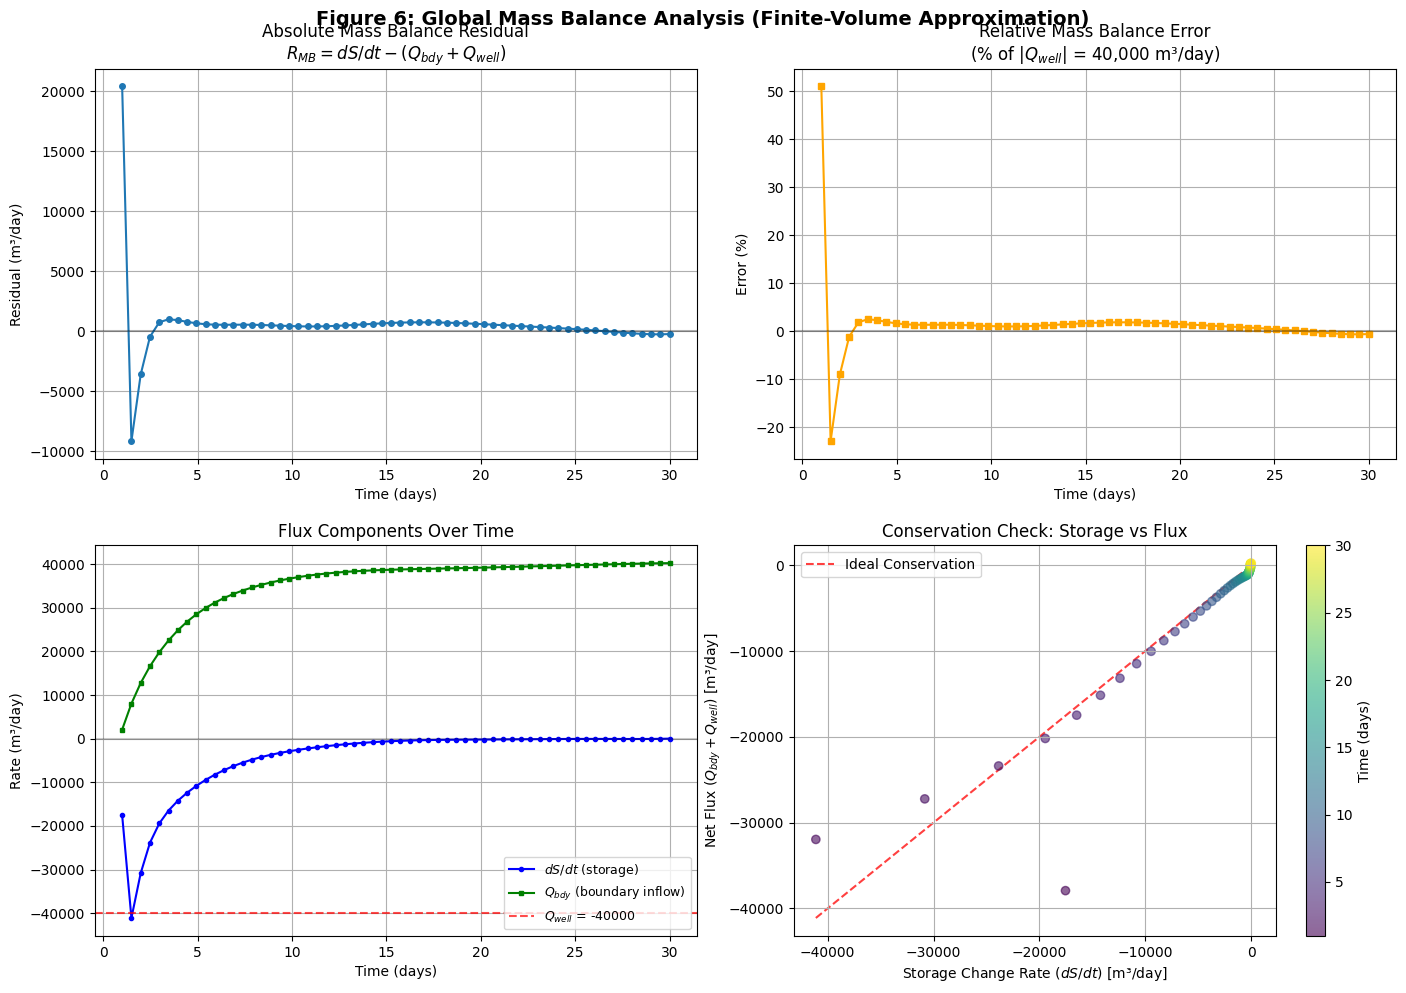

In [ ]:
# ============================================================================
# Mass Balance Error (Finite-Volume, MODFLOW-Consistent Diagnostic)
# ============================================================================
# Analyzes global mass conservation: dS/dt = Q_boundary + Q_wells
# Uses gradient-based Darcy flux at boundaries (node-centered grid)
# ============================================================================

model.eval()

# -------------------------
# 1. Setup Parameters & Grid (self-contained)
# -------------------------
K     = 33.33        # m/day
Sy    = 0.10         # Specific Yield
h0    = 90.0         # CHD boundary head (North/South)
Q_well_total = -40000.0  # m³/day (negative = pumping)
nx_mb, ny_mb = 300, 300
x_mb = np.linspace(-500, 500, nx_mb)
y_mb = np.linspace(-500, 500, ny_mb)
dx_mb = x_mb[1] - x_mb[0]
dy_mb = y_mb[1] - y_mb[0]
cell_area_mb = dx_mb * dy_mb

grid_x_mb, grid_y_mb = np.meshgrid(x_mb, y_mb)
xy_grid_mb = np.vstack([grid_x_mb.ravel(), grid_y_mb.ravel()]).T  # (N, 2)

print(f"Mass balance grid: {nx_mb}x{ny_mb}, dx={dx_mb:.2f}m, dy={dy_mb:.2f}m")

# -------------------------
# Boundary Flux via Darcy's Law (gradient-based)
# -------------------------
def boundary_flux_gradient(head_grid):
    """
    Compute net boundary inflow using Darcy's law + head gradient.
    head_grid: (ny, nx) array

    South boundary = row 0  (y = y_min = -500)
    North boundary = row -1 (y = y_max = +500)

    Returns total inflow rate (m³/day), positive = into domain.
    """
    # South boundary: inward flux (outward normal is -y)
    h_bdy_s  = head_grid[0, :]    # = 90 by hard constraint
    h_int_s  = head_grid[1, :]    # first interior row
    h_avg_s  = 0.5 * (h_bdy_s + h_int_s)
    Q_south  = np.sum(K * h_avg_s * (h_bdy_s - h_int_s) / dy_mb * dx_mb)

    # North boundary: inward flux (outward normal is +y)
    h_bdy_n  = head_grid[-1, :]   # = 90 by hard constraint
    h_int_n  = head_grid[-2, :]   # first interior row
    h_avg_n  = 0.5 * (h_bdy_n + h_int_n)
    Q_north  = np.sum(K * h_avg_n * (h_bdy_n - h_int_n) / dy_mb * dx_mb)

    return Q_south + Q_north, Q_south, Q_north

# -------------------------
# 2. Evaluate Over Time
# -------------------------
t_seq = np.linspace(1.0, 30.0, 60)

mb_errors, storage_terms, boundary_terms, forcing_terms, timesteps_plot = [], [], [], [], []

print(f"Evaluating Mass Balance over {len(t_seq)} timesteps...")

with torch.no_grad():
    for t_val in t_seq:
        # A. Predict h(t) on the mass-balance grid
        t_vec = np.full((xy_grid_mb.shape[0], 1), t_val)
        xyt_input = np.hstack([xy_grid_mb, t_vec])
        xyt_tensor = torch.from_numpy(xyt_input).float().to(device)
        h_t = model(xyt_tensor).cpu().numpy().reshape(ny_mb, nx_mb)

        # B. Predict h(t - eps) for dS/dt
        dt_deriv = 0.01
        t_prev_val = t_val - dt_deriv
        t_vec_prev = np.full((xy_grid_mb.shape[0], 1), t_prev_val)
        xyt_input_prev = np.hstack([xy_grid_mb, t_vec_prev])
        xyt_tensor_prev = torch.from_numpy(xyt_input_prev).float().to(device)
        h_prev = model(xyt_tensor_prev).cpu().numpy().reshape(ny_mb, nx_mb)

        # C. Storage change rate: sum(Sy * dh/dt * cell_area)
        dh_dt = (h_t - h_prev) / dt_deriv
        Rate_Storage = np.sum(Sy * dh_dt) * cell_area_mb

        # D. Boundary flux (gradient-based Darcy)
        Rate_Boundary, _, _ = boundary_flux_gradient(h_t)

        # E. Well flux
        Rate_Wells = Q_well_total

        # F. Residual: dS/dt should equal (boundary inflow + well extraction)
        eps_MB = Rate_Storage - (Rate_Boundary + Rate_Wells)

        mb_errors.append(eps_MB)
        storage_terms.append(Rate_Storage)
        boundary_terms.append(Rate_Boundary)
        forcing_terms.append(Rate_Boundary + Rate_Wells)
        timesteps_plot.append(t_val)

mb_errors = np.array(mb_errors)
storage_terms = np.array(storage_terms)
boundary_terms = np.array(boundary_terms)
forcing_terms = np.array(forcing_terms)
timesteps_plot = np.array(timesteps_plot)

# Relative Error — normalized by |Q_well| (stable reference scale)
# NOTE: normalizing by |net forcing| gives misleading % near steady state
# because net forcing → 0 as boundary inflow balances well pumping.
rel_MB = 100.0 * mb_errors / np.abs(Q_well_total)

print(f"\n{'='*60}")
print(f"MASS BALANCE SUMMARY")
print(f"{'='*60}")
print(f"Mean Abs Residual:   {np.mean(np.abs(mb_errors)):>10.1f} m³/day")
print(f"Max  Abs Residual:   {np.max(np.abs(mb_errors)):>10.1f} m³/day")
print(f"Mean Rel Error:      {np.mean(np.abs(rel_MB)):>10.2f} %  (of |Q_well|={np.abs(Q_well_total):.0f})")
print(f"{'='*60}")
print(f"Boundary inflow (t=1):  {boundary_terms[0]:>10.1f} m³/day")
print(f"Boundary inflow (t=30): {boundary_terms[-1]:>10.1f} m³/day")
print(f"Storage rate    (t=1):  {storage_terms[0]:>10.1f} m³/day")
print(f"Storage rate    (t=30): {storage_terms[-1]:>10.1f} m³/day")
print(f"{'='*60}")

# -------------------------
# 3. Plot
# -------------------------
fig = plt.figure(figsize=(14, 10))

ax1 = plt.subplot(2, 2, 1)
ax1.plot(timesteps_plot, mb_errors, 'o-', markersize=4, label='Residual')
ax1.axhline(0, ls='-', color='k', alpha=0.3)
ax1.set_title("Absolute Mass Balance Residual\n$R_{MB} = dS/dt - (Q_{bdy} + Q_{well})$")
ax1.set_ylabel("Residual (m³/day)")
ax1.set_xlabel("Time (days)")
ax1.grid(True)

ax2 = plt.subplot(2, 2, 2)
ax2.plot(timesteps_plot, rel_MB, 's-', markersize=4, color='orange')
ax2.axhline(0, ls='-', color='k', alpha=0.3)
ax2.set_title("Relative Mass Balance Error\n(% of $|Q_{well}|$ = 40,000 m³/day)")
ax2.set_ylabel("Error (%)")
ax2.set_xlabel("Time (days)")
ax2.grid(True)

ax3 = plt.subplot(2, 2, 3)
# Plot individual flux components over time for physical insight
ax3.plot(timesteps_plot, storage_terms, 'b-o', markersize=3, label='$dS/dt$ (storage)')
ax3.plot(timesteps_plot, boundary_terms, 'g-s', markersize=3, label='$Q_{bdy}$ (boundary inflow)')
ax3.axhline(Q_well_total, ls='--', color='r', alpha=0.7, label=f'$Q_{{well}}$ = {Q_well_total:.0f}')
ax3.axhline(0, ls='-', color='k', alpha=0.2)
ax3.set_xlabel("Time (days)")
ax3.set_ylabel("Rate (m³/day)")
ax3.set_title("Flux Components Over Time")
ax3.legend(fontsize=9)
ax3.grid(True)

ax4 = plt.subplot(2, 2, 4)
ax4.scatter(storage_terms, forcing_terms, alpha=0.6, c=timesteps_plot, cmap='viridis')
lims = [
    min(np.min(storage_terms), np.min(forcing_terms)),
    max(np.max(storage_terms), np.max(forcing_terms)),
]
ax4.plot(lims, lims, 'r--', alpha=0.75, zorder=0, label='Ideal Conservation')
ax4.set_xlabel("Storage Change Rate ($dS/dt$) [m³/day]")
ax4.set_ylabel("Net Flux ($Q_{bdy} + Q_{well}$) [m³/day]")
ax4.set_title("Conservation Check: Storage vs Flux")
cb = plt.colorbar(ax4.collections[0], ax=ax4, label='Time (days)')
ax4.legend(loc='upper left')
ax4.grid(True)

plt.suptitle(
    "Figure 6: Global Mass Balance Analysis (Finite-Volume Approximation)",
    fontweight="bold", fontsize=14
)
plt.tight_layout(pad=0.5, w_pad=0.5, h_pad=1.5)
plt.show()

## 6. Boundary Condition Analysis – Dirichlet BC Consistency

Evaluates how well the PINN respects prescribed constant-head boundaries (CHD = 90 m on North and South walls).

FIGURE 8: DIRICHLET BOUNDARY CONDITION CONSISTENCY
Evaluating ONLY prescribed boundaries (North & South)
Metric: ε_BC = |h_pred - h_BC|,  h_BC = 90 m
East/West excluded (no-flow boundaries)
--------------------------------------------------------------------------------
Found 300 points on North boundary (y=500.0)
Found 300 points on South boundary (y=-500.0)

BOUNDARY ERROR SUMMARY (Over full time sequence):
Mean MAE:  0.0000 m
Max Error: 0.0000 m (Worst case)
99th pct:  0.0000 m


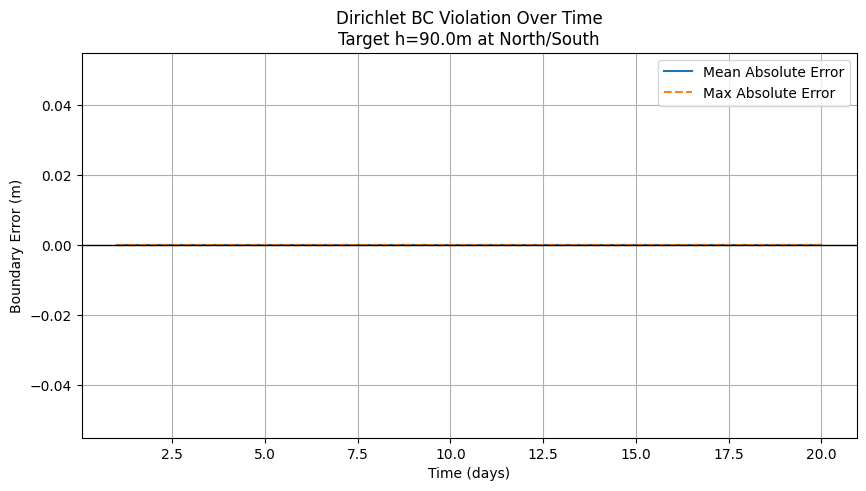

In [ ]:
# ============================================================================
# Dirichlet Boundary Condition Error
# ============================================================================
# Evaluates consistency with prescribed head h = 90.0 at North/South boundaries

model.eval()

h0 = 90.0  # Prescribed CHD head (North & South only)

print("=" * 80)
print("FIGURE 8: DIRICHLET BOUNDARY CONDITION CONSISTENCY")
print("=" * 80)
print("Evaluating ONLY prescribed boundaries (North & South)")
print("Metric: ε_BC = |h_pred - h_BC|,  h_BC = 90 m")
print("East/West excluded (no-flow boundaries)")
print("-" * 80)

# Dependencies check
if 'xy_grid_val' not in globals():
    print("⚠️ 'xy_grid_val' missing. Please run the 'PDE Residual Evaluation' cell first.")
else:

    if 't_seq' not in globals():
        t_seq = np.linspace(1.0, 20.0, 50)

    boundary_errors_all = []
    mae_over_time = []
    max_over_time = []
    y_coords = xy_grid_val[:, 1]
    y_max = np.max(y_coords)
    y_min = np.min(y_coords)

    # Indices where y is approx y_max or y_min
    north_mask = np.isclose(y_coords, y_max)
    south_mask = np.isclose(y_coords, y_min)

    idx_north = np.where(north_mask)[0]
    idx_south = np.where(south_mask)[0]

    print(f"Found {len(idx_north)} points on North boundary (y={y_max})")
    print(f"Found {len(idx_south)} points on South boundary (y={y_min})")

    with torch.no_grad():
        for t_val in t_seq:

            t_vec = np.full((xy_grid_val.shape[0], 1), t_val)
            xyt_input = np.hstack([xy_grid_val, t_vec])
            xyt_tensor = torch.from_numpy(xyt_input).float().to(device)

            h_pred = model(xyt_tensor).cpu().numpy().flatten()

            # Extract Boundary Heads
            h_north = h_pred[idx_north]
            h_south = h_pred[idx_south]

            # Known BCs
            bc_north = np.full_like(h_north, h0)
            bc_south = np.full_like(h_south, h0)

            # Errors
            err_north = np.abs(h_north - bc_north)
            err_south = np.abs(h_south - bc_south)

            # Combine
            err_total = np.concatenate([err_north, err_south])

            boundary_errors_all.extend(err_total)
            mae_over_time.append(np.mean(err_total))
            max_over_time.append(np.max(err_total))

    boundary_errors_all = np.array(boundary_errors_all)
    mae_over_time = np.array(mae_over_time)
    max_over_time = np.array(max_over_time)

    print("\nBOUNDARY ERROR SUMMARY (Over full time sequence):")
    print(f"Mean MAE:  {mae_over_time.mean():.4f} m")
    print(f"Max Error: {max_over_time.max():.4f} m (Worst case)")
    print(f"99th pct:  {np.percentile(boundary_errors_all, 99):.4f} m")
    print("=" * 80)

    # Plotting
    fig, ax = plt.figure(figsize=(10, 5)), plt.gca()
    plt.plot(t_seq, mae_over_time, label='Mean Absolute Error')
    plt.plot(t_seq, max_over_time, label='Max Absolute Error', linestyle='--')
    plt.axhline(0, color='k', lw=1)

    plt.xlabel('Time (days)')
    plt.ylabel('Boundary Error (m)')
    plt.title(f'Dirichlet BC Violation Over Time\nTarget h={h0}m at North/South')
    plt.legend()
    plt.grid(True)
    plt.show()